# Exact Closed Ancestral Cones in the 25 kb Synthetic ARG

This notebook finds **minimal exact closed ancestral cones** at every event boundary in a synthetic/full ARG. For a cut at step `k`, events `[0, k)` are fixed below the cut and events `[k, N)` form the older suffix. A discovered cone is a contiguous proper genomic interval whose complete older event/edge closure is isolated from the rest of the chromosome.

The notebook intentionally performs an all-cut $O(N^2)$ scan on the small 25 kb fixture. It discovers structure only; it does not reconstruct a replacement ARG or compute an RL/GFlowNet reward.

## Build, save, certify, and trace the synthetic/full ARG

The complete input flow is performed here before any region discovery:

1. load the ordinary inferred 25 kb tree sequence;
2. convert it with `build_synthetic_full_arg`, using balanced synthetic recombination topology and globally unique event times;
3. write the converted tree sequence to a distinct `new_rl` `.trees` file and reload it, exercising the same serialized artifact used downstream;
4. certify its provenance and paired recombination nodes;
5. build the strict backward-time event trace used by the exact-cone scan.

A recombination event contains two synthetic nodes at the same time. Time uniqueness applies between distinct ARG events.

In [1]:
from __future__ import annotations

import copy
from pathlib import Path
import sys
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"Pandas requires version .* of 'numexpr'",
    )
    import pandas as pd
import tskit


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start).expanduser().resolve()
    fallback = Path("/Users/pratik/Documents/work/aim3/simpliied")
    for candidate in (start, *start.parents, fallback):
        if (candidate / "arg/new_rl/trace.py").is_file() and (
            candidate / "arg/new_rl/synthetic_full_arg.py"
        ).is_file():
            return candidate
    raise RuntimeError("Could not locate the workspace root")


WORKSPACE_ROOT = find_workspace_root()
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from arg.new_rl import (
    NODE_IS_RE_EVENT,
    build_fast_trace_from_full_arg,
    build_synthetic_full_arg,
    get_synthetic_full_arg_provenance,
)
from arg.new_rl.trace import (
    EVENT_KIND_COALESCENCE,
    EVENT_KIND_NAMES,
    EVENT_KIND_RECOMBINATION,
)

INPUT_TREE_PATH = (
    WORKSPACE_ROOT
    / "arg/validation/output/tsinfer/l25kb_dated.trees"
)
SYNTHETIC_TREE_PATH = (
    WORKSPACE_ROOT
    / (
        "arg/validation/output/tsinfer/"
        "l25kb_dated_new_rl_synthetic_full_arg.trees"
    )
)
if not INPUT_TREE_PATH.is_file():
    raise FileNotFoundError(INPUT_TREE_PATH)


# 1) Load the ordinary inferred tree sequence.
input_tree_sequence = tskit.load(str(INPUT_TREE_PATH))

# 2) Insert paired recombination nodes and make event times unique.
synthetic_conversion = build_synthetic_full_arg(
    input_tree_sequence,
    split_rule="balanced",
    ensure_unique_event_times=True,
)

# 3) Serialize and reload the exact artifact consumed below.
SYNTHETIC_TREE_PATH.parent.mkdir(parents=True, exist_ok=True)
synthetic_conversion.tree_sequence.dump(str(SYNTHETIC_TREE_PATH))
synthetic_arg = tskit.load(str(SYNTHETIC_TREE_PATH))

conversion_summary = {
    "normal_input_path": str(INPUT_TREE_PATH),
    "synthetic_output_path": str(SYNTHETIC_TREE_PATH),
    "input_trees": int(input_tree_sequence.num_trees),
    "input_nodes": int(input_tree_sequence.num_nodes),
    "input_edges": int(input_tree_sequence.num_edges),
    "synthetic_trees": int(synthetic_arg.num_trees),
    "synthetic_nodes": int(synthetic_arg.num_nodes),
    "synthetic_edges": int(synthetic_arg.num_edges),
    "synthetic_recombination_events": synthetic_conversion.metadata[
        "synthetic_recombination_event_count"
    ],
    "adjusted_event_times": synthetic_conversion.metadata[
        "event_time_adjusted_event_count"
    ],
}
display(conversion_summary)

# 4) Certify the reloaded file before constructing the trace.
synthetic_provenance = get_synthetic_full_arg_provenance(synthetic_arg)
if synthetic_provenance is None:
    raise ValueError("Input lacks synthetic/full-ARG provenance")
parameters = synthetic_provenance.get("parameters", {})
provenance_summary = synthetic_provenance.get("summary", {})
if parameters.get("ensure_unique_event_times") is not True:
    raise ValueError("Synthetic ARG was not built with unique event times")
if provenance_summary.get("event_times_are_globally_unique") is not True:
    raise ValueError("Synthetic ARG is not certified to have unique event times")

node_flags = np.asarray(synthetic_arg.nodes_flags, dtype=np.uint32)
recombination_node_ids = np.flatnonzero(
    (node_flags & int(NODE_IS_RE_EVENT)) != 0
)
if recombination_node_ids.size == 0 or recombination_node_ids.size % 2:
    raise ValueError("Expected a nonzero even number of recombination nodes")

# 5) Materialize the strict event schedule used by all later cuts.
trace = build_fast_trace_from_full_arg(
    synthetic_arg,
    require_unique_event_times=True,
)
if trace.event_count > 1 and not np.all(np.diff(trace.event_time) > 0.0):
    raise AssertionError("Distinct ARG event times must be strictly increasing")
if trace.recombination_event_count * 2 != recombination_node_ids.size:
    raise AssertionError("Recombination node pairs do not match trace events")

terminal_state = trace.initial_state().advance_to(trace.num_steps)
terminal_frontier = terminal_state.compact_active_frontier()

trace_input_summary = {
    "synthetic_path": str(SYNTHETIC_TREE_PATH),
    "sequence_length": float(synthetic_arg.sequence_length),
    "trees": int(synthetic_arg.num_trees),
    "samples": int(synthetic_arg.num_samples),
    "nodes": int(synthetic_arg.num_nodes),
    "edges": int(synthetic_arg.num_edges),
    "events": int(trace.event_count),
    "recombination_events": int(trace.recombination_event_count),
    "coalescence_events": int(trace.coalescence_event_count),
    "event_times_strictly_increasing": True,
    "synthetic_provenance_parameters": parameters,
}
display(trace_input_summary)


{'normal_input_path': '/Users/pratik/Documents/work/aim3/simpliied/arg/validation/output/tsinfer/l25kb_dated.trees',
 'synthetic_output_path': '/Users/pratik/Documents/work/aim3/simpliied/arg/validation/output/tsinfer/l25kb_dated_new_rl_synthetic_full_arg.trees',
 'input_trees': 9,
 'input_nodes': 20,
 'input_edges': 30,
 'synthetic_trees': 9,
 'synthetic_nodes': 46,
 'synthetic_edges': 65,
 'synthetic_recombination_events': 13,
 'adjusted_event_times': 0}

{'synthetic_path': '/Users/pratik/Documents/work/aim3/simpliied/arg/validation/output/tsinfer/l25kb_dated_new_rl_synthetic_full_arg.trees',
 'sequence_length': 25000.0,
 'trees': 9,
 'samples': 8,
 'nodes': 46,
 'edges': 65,
 'events': 25,
 'recombination_events': 13,
 'coalescence_events': 12,
 'event_times_strictly_increasing': True,
 'synthetic_provenance_parameters': {'ensure_unique_event_times': True,
  'event_time_adjustment_rule': 'scale_aware_bidirectional_spacing',
  'node_flag': 131072,
  'split_rule': 'balanced',
  'time_rule': 'midpoint'}}

## Exact suffix closure

At one cut, each active lineage starts as a union-find item. Disjoint material carried by one lineage stays together, overlapping material across lineages is joined, and every older event joins all components containing its children. The resulting roots are the minimal components that can be reconstructed without changing an outside suffix event.

In [2]:
def uf_find(parent, item):
    item = int(item)
    root = item
    while int(parent[root]) != root:
        root = int(parent[root])
    while int(parent[item]) != item:
        following = int(parent[item])
        parent[item] = root
        item = following
    return root


def uf_union(parent, sizes, left_item, right_item):
    left_root = uf_find(parent, left_item)
    right_root = uf_find(parent, right_item)
    if left_root == right_root:
        return left_root
    if int(sizes[left_root]) < int(sizes[right_root]):
        left_root, right_root = right_root, left_root
    parent[right_root] = left_root
    sizes[left_root] += sizes[right_root]
    return left_root


def initial_material_components(segment_offsets, segment_left, segment_right):
    segment_offsets = np.asarray(segment_offsets, dtype=np.int64)
    segment_left = np.asarray(segment_left, dtype=np.float64)
    segment_right = np.asarray(segment_right, dtype=np.float64)
    if segment_offsets.ndim != 1 or segment_offsets.size == 0:
        raise ValueError("segment_offsets must be a nonempty vector")
    if segment_left.shape != segment_right.shape or segment_left.ndim != 1:
        raise ValueError("segment arrays must be matching vectors")
    if int(segment_offsets[0]) != 0 or int(segment_offsets[-1]) != segment_left.size:
        raise ValueError("segment_offsets do not span the segment arrays")
    if np.any(segment_left >= segment_right):
        raise ValueError("all material intervals must be nonempty")

    lineage_count = segment_offsets.size - 1
    parent = np.arange(lineage_count, dtype=np.int32)
    sizes = np.ones(lineage_count, dtype=np.int32)
    segment_owner = np.empty(segment_left.size, dtype=np.int32)
    for lineage_index in range(lineage_count):
        start = int(segment_offsets[lineage_index])
        end = int(segment_offsets[lineage_index + 1])
        segment_owner[start:end] = lineage_index

    order = np.argsort(segment_left, kind="stable")
    run_owner = -1
    run_right = -np.inf
    for segment_index in order:
        owner = int(segment_owner[segment_index])
        left = float(segment_left[segment_index])
        right = float(segment_right[segment_index])
        if run_owner < 0 or left >= run_right:
            run_owner = owner
            run_right = right
        else:
            uf_union(parent, sizes, run_owner, owner)
            run_right = max(run_right, right)

    lineage_roots = np.asarray(
        [uf_find(parent, index) for index in range(lineage_count)],
        dtype=np.int32,
    )
    return {
        "parent": parent,
        "sizes": sizes,
        "segment_owner": segment_owner,
        "lineage_roots": lineage_roots,
    }


def close_components_through_suffix(
    frontier_node_ids,
    cut_step,
    event_node1,
    event_node2,
    event_edge_start,
    revealed_edge_ids,
    edge_child,
    node_count,
    parent,
    sizes,
):
    frontier_node_ids = np.asarray(frontier_node_ids, dtype=np.int32)
    node_component = np.full(int(node_count), -1, dtype=np.int32)
    for lineage_index, node_id in enumerate(frontier_node_ids):
        node_component[int(node_id)] = lineage_index

    event_roots = np.full(len(event_node1) - int(cut_step), -1, dtype=np.int32)
    for event_index in range(int(cut_step), len(event_node1)):
        edge_start = int(event_edge_start[event_index])
        edge_end = int(event_edge_start[event_index + 1])
        if edge_start == edge_end:
            continue
        event_root = -1
        for edge_position in range(edge_start, edge_end):
            edge_id = int(revealed_edge_ids[edge_position])
            child_id = int(edge_child[edge_id])
            child_component = int(node_component[child_id])
            if child_component < 0:
                raise RuntimeError(
                    f"event {event_index} references unassigned child node {child_id}"
                )
            if event_root < 0:
                event_root = uf_find(parent, child_component)
            else:
                event_root = uf_union(parent, sizes, event_root, child_component)

        for node_id in (int(event_node1[event_index]), int(event_node2[event_index])):
            if node_id < 0:
                continue
            previous = int(node_component[node_id])
            if previous >= 0:
                event_root = uf_union(parent, sizes, event_root, previous)
            node_component[node_id] = event_root
        event_roots[event_index - int(cut_step)] = event_root

    frontier_roots = np.asarray(
        [uf_find(parent, index) for index in range(frontier_node_ids.size)],
        dtype=np.int32,
    )
    for offset, root in enumerate(event_roots):
        if root >= 0:
            event_roots[offset] = uf_find(parent, int(root))
    return parent, sizes, frontier_roots, event_roots, node_component


def canonical_component_intervals(
    component_count, segment_component, segment_left, segment_right
):
    buckets = [[] for _ in range(int(component_count))]
    for component, left, right in zip(
        segment_component, segment_left, segment_right
    ):
        buckets[int(component)].append((float(left), float(right)))

    output = []
    for intervals in buckets:
        merged = []
        for left, right in sorted(intervals):
            if merged and left <= merged[-1][1]:
                merged[-1] = (merged[-1][0], max(merged[-1][1], right))
            else:
                merged.append((left, right))
        output.append(tuple(merged))
    return output


In [3]:
def event_edge_ids(local_trace, event_index):
    start = int(local_trace.event_edge_start[int(event_index)])
    end = int(local_trace.event_edge_start[int(event_index) + 1])
    return np.asarray(local_trace.revealed_edge_ids[start:end], dtype=np.int32)


def grouped_values(values, labels, component_count):
    groups = [[] for _ in range(int(component_count))]
    for value, label in zip(values, labels):
        label = int(label)
        if label < 0 or label >= component_count:
            raise AssertionError(f"invalid component label {label}")
        groups[label].append(int(value))
    return groups


def exact_components_at_cut(state, cut_step, reference_terminal_frontier):
    local_trace = state.trace
    cut_step = int(cut_step)
    if state.step != cut_step:
        raise ValueError(f"state is at step {state.step}, expected {cut_step}")
    frontier = state.compact_active_frontier()
    if frontier.node_ids.size == 0 or frontier.segment_count == 0:
        raise RuntimeError(f"cut step {cut_step} has an empty frontier")

    initial = initial_material_components(
        frontier.segment_offsets, frontier.segment_left, frontier.segment_right
    )
    parent, sizes, frontier_roots, event_roots, node_component = (
        close_components_through_suffix(
            frontier.node_ids,
            cut_step,
            local_trace.event_node1,
            local_trace.event_node2,
            local_trace.event_edge_start,
            local_trace.revealed_edge_ids,
            local_trace.edge_child,
            local_trace.node_time.size,
            initial["parent"],
            initial["sizes"],
        )
    )

    final_roots = np.unique(frontier_roots)
    root_to_component = {int(root): index for index, root in enumerate(final_roots)}
    frontier_components = np.asarray(
        [root_to_component[uf_find(parent, int(root))] for root in frontier_roots],
        dtype=np.int32,
    )

    suffix_event_indices = np.arange(cut_step, local_trace.num_steps, dtype=np.int64)
    suffix_edgeful = (
        np.diff(local_trace.event_edge_start[cut_step:]) > 0
        if cut_step < local_trace.num_steps
        else np.empty(0, dtype=bool)
    )
    event_components = np.full(event_roots.size, -1, dtype=np.int32)
    for offset, root in enumerate(event_roots):
        if root >= 0:
            event_components[offset] = root_to_component[uf_find(parent, int(root))]
    if not np.array_equal(event_components >= 0, suffix_edgeful):
        raise AssertionError("every edgeful suffix event must have one component")

    terminal_components = []
    for node_id in reference_terminal_frontier.node_ids:
        seed = int(node_component[int(node_id)])
        if seed < 0:
            raise RuntimeError(f"terminal node {int(node_id)} has no component")
        terminal_components.append(root_to_component[uf_find(parent, seed)])
    terminal_components = np.asarray(terminal_components, dtype=np.int32)

    segment_components = frontier_components[initial["segment_owner"]]
    intervals_by_component = canonical_component_intervals(
        len(final_roots),
        segment_components,
        frontier.segment_left,
        frontier.segment_right,
    )
    lower_nodes = grouped_values(
        frontier.node_ids, frontier_components, len(final_roots)
    )
    terminal_nodes = grouped_values(
        reference_terminal_frontier.node_ids,
        terminal_components,
        len(final_roots),
    )
    events_by_component = grouped_values(
        suffix_event_indices[suffix_edgeful],
        event_components[suffix_edgeful],
        len(final_roots),
    )

    separation_event = (
        None if cut_step == 0 else local_trace.event_at_index(cut_step - 1)
    )
    candidates = []
    for component_index, intervals in enumerate(intervals_by_component):
        component_events = np.asarray(
            events_by_component[component_index], dtype=np.int64
        )
        component_edge_chunks = [
            event_edge_ids(local_trace, event_index)
            for event_index in component_events
        ]
        component_edge_ids = (
            np.unique(np.concatenate(component_edge_chunks)).astype(np.int32)
            if component_edge_chunks
            else np.empty(0, dtype=np.int32)
        )
        outside_event_indices = suffix_event_indices[
            suffix_edgeful & (event_components != component_index)
        ]
        outside_edge_chunks = [
            event_edge_ids(local_trace, event_index)
            for event_index in outside_event_indices
        ]
        outside_edge_ids = (
            np.unique(np.concatenate(outside_edge_chunks)).astype(np.int32)
            if outside_edge_chunks
            else np.empty(0, dtype=np.int32)
        )

        left = float(intervals[0][0])
        right = float(intervals[-1][1])
        contiguous = len(intervals) == 1
        proper_subregion = not (
            left <= 0.0 and right >= float(local_trace.sequence_length)
        )
        assigned_edges_inside = bool(
            np.all(local_trace.edge_left[component_edge_ids] >= left)
            and np.all(local_trace.edge_right[component_edge_ids] <= right)
        )
        outside_overlap_edge_ids = outside_edge_ids[
            (local_trace.edge_left[outside_edge_ids] < right)
            & (local_trace.edge_right[outside_edge_ids] > left)
        ]

        reasons = []
        if not contiguous:
            reasons.append("noncontiguous")
        if not proper_subregion:
            reasons.append("whole_sequence")
        if component_events.size == 0:
            reasons.append("zero_event")
        if not assigned_edges_inside:
            reasons.append("assigned_edge_outside_region")
        if outside_overlap_edge_ids.size:
            reasons.append("outside_suffix_edge_overlap")

        component_lineages = np.flatnonzero(frontier_components == component_index)
        frontier_segments = []
        for lineage_index in component_lineages:
            start = int(frontier.segment_offsets[lineage_index])
            end = int(frontier.segment_offsets[lineage_index + 1])
            for segment_index in range(start, end):
                frontier_segments.append(
                    (
                        int(frontier.node_ids[lineage_index]),
                        float(frontier.segment_left[segment_index]),
                        float(frontier.segment_right[segment_index]),
                    )
                )

        event_node_values = []
        for event_index in component_events:
            for node_id in (
                int(local_trace.event_node1[event_index]),
                int(local_trace.event_node2[event_index]),
            ):
                if node_id >= 0:
                    event_node_values.append(node_id)
        node_values = list(lower_nodes[component_index])
        node_values.extend(terminal_nodes[component_index])
        node_values.extend(event_node_values)
        if component_edge_ids.size:
            node_values.extend(local_trace.edge_parent[component_edge_ids].tolist())
            node_values.extend(local_trace.edge_child[component_edge_ids].tolist())
        component_node_ids = tuple(sorted(set(int(v) for v in node_values)))

        event_kinds = local_trace.event_kind[component_events]
        material_length = float(sum(b - a for a, b in intervals))
        candidates.append(
            {
                "boundary_step": cut_step,
                "boundary_time": float(state.current_time),
                "component_index": component_index,
                "region_key": (left, right) if contiguous else tuple(intervals),
                "intervals": tuple(intervals),
                "left": left,
                "right": right,
                "span": right - left,
                "material_length": material_length,
                "contiguous": contiguous,
                "proper_subregion": proper_subregion,
                "lower_frontier_anchor_node_ids": tuple(
                    lower_nodes[component_index]
                ),
                "frontier_segments": tuple(frontier_segments),
                "suffix_event_indices": tuple(int(v) for v in component_events),
                "edge_ids": tuple(int(v) for v in component_edge_ids),
                "node_ids": component_node_ids,
                "terminal_lineage_ids": tuple(terminal_nodes[component_index]),
                "event_count": int(component_events.size),
                "recombination_event_count": int(
                    np.sum(event_kinds == EVENT_KIND_RECOMBINATION)
                ),
                "coalescence_event_count": int(
                    np.sum(event_kinds == EVENT_KIND_COALESCENCE)
                ),
                "node_count": len(component_node_ids),
                "edge_count": int(component_edge_ids.size),
                "assigned_edges_inside": assigned_edges_inside,
                "outside_overlap_edge_ids": tuple(
                    int(v) for v in outside_overlap_edge_ids
                ),
                "closure_verified": assigned_edges_inside
                and not outside_overlap_edge_ids.size,
                "exact": not reasons,
                "rejection_reasons": tuple(reasons),
                "separation_event_index": (
                    None if separation_event is None else cut_step - 1
                ),
                "separation_event_time": (
                    None if separation_event is None else separation_event.time
                ),
                "separation_event_kind": (
                    None if separation_event is None else separation_event.kind
                ),
                "separation_event_node_ids": (
                    () if separation_event is None else separation_event.node_ids
                ),
            }
        )

    candidates.sort(key=lambda item: (item["left"], item["right"]))
    for candidate_index, candidate in enumerate(candidates):
        candidate["candidate_id"] = (
            f"step-{cut_step}-component-{candidate_index:04d}"
        )

    if sum(candidate["event_count"] for candidate in candidates) != int(
        np.sum(suffix_edgeful)
    ):
        raise AssertionError("suffix events do not partition across components")
    exact_intervals = sorted(
        (candidate["left"], candidate["right"])
        for candidate in candidates
        if candidate["exact"]
    )
    for previous, current in zip(exact_intervals, exact_intervals[1:]):
        if current[0] < previous[1]:
            raise AssertionError("exact components overlap at one cut")

    return {
        "boundary_step": cut_step,
        "boundary_time": float(state.current_time),
        "suffix_event_count": int(local_trace.num_steps - cut_step),
        "frontier_lineage_count": int(frontier.node_ids.size),
        "frontier_segment_count": int(frontier.segment_count),
        "component_count": len(candidates),
        "exact_component_count": sum(candidate["exact"] for candidate in candidates),
        "candidates": candidates,
    }

# The notebook retains the helper definitions above for diagnostic cells,
# but all production cut classification now uses the shared module.
from arg.new_rl.exact_closed_cones import (
    exact_components_at_cut,
    scan_exact_closed_cones,
)


## Helper-level structural checks

In [4]:
# Independent disjoint regions remain separate.
_independent = initial_material_components(
    np.array([0, 1, 2], dtype=np.int64),
    np.array([0.0, 150.0]),
    np.array([100.0, 250.0]),
)
assert np.unique(_independent["lineage_roots"]).size == 2

# Half-open intervals touching at one endpoint remain separate.
_touching = initial_material_components(
    np.array([0, 1, 2], dtype=np.int64),
    np.array([0.0, 100.0]),
    np.array([100.0, 200.0]),
)
assert np.unique(_touching["lineage_roots"]).size == 2

# Disjoint material on one lineage remains one noncontiguous component.
_one_lineage = initial_material_components(
    np.array([0, 2], dtype=np.int64),
    np.array([0.0, 20.0]),
    np.array([10.0, 30.0]),
)
_one_intervals = canonical_component_intervals(
    1,
    np.zeros(2, dtype=np.int32),
    np.array([0.0, 20.0]),
    np.array([10.0, 30.0]),
)
assert _one_intervals == [((0.0, 10.0), (20.0, 30.0))]

# A later event consuming both children joins two initially independent regions.
_join_initial = initial_material_components(
    np.array([0, 1, 2], dtype=np.int64),
    np.array([0.0, 150.0]),
    np.array([100.0, 250.0]),
)
_, _, _joined_roots, _joined_events, _ = close_components_through_suffix(
    np.array([0, 1], dtype=np.int32),
    0,
    np.array([2], dtype=np.int32),
    np.array([-1], dtype=np.int32),
    np.array([0, 2], dtype=np.int64),
    np.array([0, 1], dtype=np.int32),
    np.array([0, 1], dtype=np.int32),
    3,
    _join_initial["parent"],
    _join_initial["sizes"],
)
assert np.unique(_joined_roots).size == 1
assert _joined_events[0] == _joined_roots[0]

helper_validation_summary = {
    "independent_regions": "passed",
    "later_event_coupling": "passed",
    "half_open_endpoint": "passed",
    "disjoint_one_lineage": "passed",
}
display(helper_validation_summary)


{'independent_regions': 'passed',
 'later_event_coupling': 'passed',
 'half_open_endpoint': 'passed',
 'disjoint_one_lineage': 'passed'}

## Scan every event boundary and retain each cone's earliest cut

In [5]:
exact_cone_scan_result = scan_exact_closed_cones(
    trace, retain_per_cut_catalog=True
)
per_cut_component_catalog = list(
    exact_cone_scan_result.per_cut_component_catalog
)

raw_exact_candidates = [
    candidate
    for cut_result in per_cut_component_catalog
    for candidate in cut_result["candidates"]
    if candidate["exact"]
]

candidates_by_region = {}
for candidate in sorted(
    raw_exact_candidates,
    key=lambda item: (item["boundary_step"], item["left"], item["right"]),
):
    candidates_by_region.setdefault(candidate["region_key"], []).append(candidate)

exact_closed_cones = []
for region_key, occurrences in candidates_by_region.items():
    earliest = copy.deepcopy(occurrences[0])
    latest = occurrences[-1]
    earliest["first_closed_step"] = int(earliest["boundary_step"])
    earliest["first_closed_time"] = float(earliest["boundary_time"])
    earliest["last_closed_step"] = int(latest["boundary_step"])
    earliest["last_closed_time"] = float(latest["boundary_time"])
    earliest["valid_cut_count"] = len(occurrences)
    earliest["valid_cut_steps"] = tuple(
        int(item["boundary_step"]) for item in occurrences
    )
    exact_closed_cones.append(earliest)

exact_closed_cones.sort(
    key=lambda item: (item["first_closed_step"], item["left"], item["right"])
)
for cone_index, cone in enumerate(exact_closed_cones):
    cone["cone_id"] = f"cone-{cone_index:04d}"

per_cut_summary_df = pd.DataFrame(
    [
        {
            "boundary_step": item["boundary_step"],
            "boundary_time": item["boundary_time"],
            "suffix_events": item["suffix_event_count"],
            "frontier_lineages": item["frontier_lineage_count"],
            "frontier_segments": item["frontier_segment_count"],
            "components": item["component_count"],
            "exact_nonempty_components": item["exact_component_count"],
        }
        for item in per_cut_component_catalog
    ]
)

exact_closed_cones_df = pd.DataFrame(
    [
        {
            "cone_id": cone["cone_id"],
            "left": cone["left"],
            "right": cone["right"],
            "span": cone["span"],
            "cut_step": cone["first_closed_step"],
            "cut_time": cone["first_closed_time"],
            "separation_event_index": cone["separation_event_index"],
            "separation_event_kind": cone["separation_event_kind"],
            "frontier_lineage_count": len(
                cone["lower_frontier_anchor_node_ids"]
            ),
            "event_count": cone["event_count"],
            "recombination_events": cone["recombination_event_count"],
            "coalescence_events": cone["coalescence_event_count"],
            "node_count": cone["node_count"],
            "edge_count": cone["edge_count"],
            "last_closed_step": cone["last_closed_step"],
            "last_closed_time": cone["last_closed_time"],
            "valid_cut_count": cone["valid_cut_count"],
        }
        for cone in exact_closed_cones
    ]
)

display(per_cut_summary_df)
display(exact_closed_cones_df)


,boundary_step,boundary_time,suffix_events,frontier_lineages,frontier_segments,components,exact_nonempty_components
0,0,0.000000,25,8,8,1,0
1,1,629.632368,24,10,11,1,0
2,2,779.228805,23,11,14,1,0
3,3,944.448552,22,13,17,1,0
4,4,1259.264736,21,14,18,1,0
5,5,1732.484917,20,15,21,1,0
6,6,1888.897104,19,14,20,1,0
7,7,2810.295107,18,14,21,1,0
8,8,2949.117101,17,16,24,2,1
9,9,4319.559156,16,17,25,2,1


,cone_id,left,right,span,cut_step,cut_time,separation_event_index,separation_event_kind,frontier_lineage_count,event_count,recombination_events,coalescence_events,node_count,edge_count,last_closed_step,last_closed_time,valid_cut_count
0,cone-0000,386.0,23963.0,23577.0,8,2949.117101,7,recombination,8,17,9,8,34,46,17,24677.106130,10
1,cone-0001,386.0,9543.0,9157.0,18,27617.469048,17,recombination,4,3,1,2,8,8,24,58442.228572,7
2,cone-0002,22242.0,23963.0,1721.0,18,27617.469048,17,recombination,2,4,2,2,8,8,21,33498.194884,4
3,cone-0003,22242.0,22880.0,638.0,22,38946.101470,21,recombination,2,1,0,1,3,2,22,38946.101470,1
4,cone-0004,22880.0,23963.0,1083.0,22,38946.101470,21,recombination,2,1,0,1,3,2,23,50274.733893,2


## Full 25 kb validation

In [6]:
if not exact_closed_cones:
    raise AssertionError("The 25 kb fixture produced no nonempty exact cones")

for cut_result in per_cut_component_catalog:
    suffix_edgeful_count = sum(
        candidate["event_count"] for candidate in cut_result["candidates"]
    )
    expected_edgeful_count = sum(
        int(trace.event_edge_start[index + 1])
        > int(trace.event_edge_start[index])
        for index in range(cut_result["boundary_step"], trace.num_steps)
    )
    assert suffix_edgeful_count == expected_edgeful_count

    exact_at_cut = sorted(
        (candidate["left"], candidate["right"])
        for candidate in cut_result["candidates"]
        if candidate["exact"]
    )
    assert all(
        current[0] >= previous[1]
        for previous, current in zip(exact_at_cut, exact_at_cut[1:])
    )

for cone in exact_closed_cones:
    assert cone["event_count"] > 0
    assert cone["contiguous"] and cone["proper_subregion"]
    assert cone["closure_verified"]
    assert cone["assigned_edges_inside"]
    assert not cone["outside_overlap_edge_ids"]
    assert cone["first_closed_step"] == min(cone["valid_cut_steps"])
    earlier_matches = [
        candidate
        for cut_result in per_cut_component_catalog
        if cut_result["boundary_step"] < cone["first_closed_step"]
        for candidate in cut_result["candidates"]
        if candidate["exact"] and candidate["region_key"] == cone["region_key"]
    ]
    assert not earlier_matches

validation_summary = {
    "synthetic_full_arg_certified": True,
    "unique_event_times_verified": True,
    "all_event_boundaries_scanned": len(per_cut_component_catalog),
    "raw_exact_candidates": len(raw_exact_candidates),
    "deduplicated_exact_closed_cones": len(exact_closed_cones),
    "minimum_discovered_span": min(cone["span"] for cone in exact_closed_cones),
    "sub_1kb_cones_retained": sum(
        cone["span"] < 1000.0 for cone in exact_closed_cones
    ),
    "edge_containment_verified": True,
    "outside_suffix_overlap_absent": True,
}
display(validation_summary)


{'synthetic_full_arg_certified': True,
 'unique_event_times_verified': True,
 'all_event_boundaries_scanned': 26,
 'raw_exact_candidates': 24,
 'deduplicated_exact_closed_cones': 5,
 'minimum_discovered_span': 638.0,
 'sub_1kb_cones_retained': 1,
 'edge_containment_verified': True,
 'outside_suffix_overlap_absent': True}

## Space-time summaries

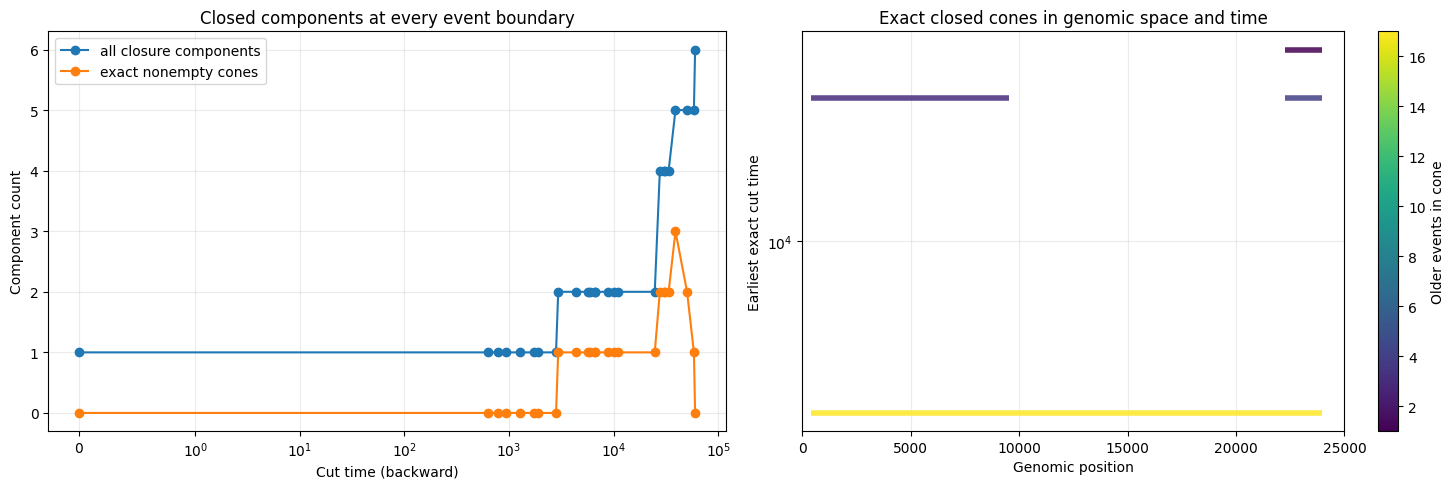

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(
    per_cut_summary_df["boundary_time"],
    per_cut_summary_df["components"],
    marker="o",
    label="all closure components",
)
axes[0].plot(
    per_cut_summary_df["boundary_time"],
    per_cut_summary_df["exact_nonempty_components"],
    marker="o",
    label="exact nonempty cones",
)
axes[0].set_xscale("symlog", linthresh=1.0)
axes[0].set_xlabel("Cut time (backward)")
axes[0].set_ylabel("Component count")
axes[0].set_title("Closed components at every event boundary")
axes[0].legend()
axes[0].grid(alpha=0.25)

event_counts = np.asarray([cone["event_count"] for cone in exact_closed_cones])
normalizer = plt.Normalize(vmin=event_counts.min(), vmax=max(event_counts.max(), 1))
color_map = plt.get_cmap("viridis")
for cone in exact_closed_cones:
    color = color_map(normalizer(cone["event_count"]))
    axes[1].hlines(
        cone["first_closed_time"],
        cone["left"],
        cone["right"],
        color=color,
        linewidth=4,
        alpha=0.85,
    )
axes[1].set_yscale("symlog", linthresh=1.0)
axes[1].set_xlim(0.0, float(trace.sequence_length))
axes[1].set_xlabel("Genomic position")
axes[1].set_ylabel("Earliest exact cut time")
axes[1].set_title("Exact closed cones in genomic space and time")
axes[1].grid(alpha=0.25)
fig.colorbar(
    plt.cm.ScalarMappable(norm=normalizer, cmap=color_map),
    ax=axes[1],
    label="Older events in cone",
)
fig.tight_layout()
plt.show()


## Candidate inspector and detailed edge-containment plot

{'cone_id': 'cone-0000',
 'left': 386.0,
 'right': 23963.0,
 'span': 23577.0,
 'first_closed_step': 8,
 'first_closed_time': 2949.117100931699,
 'separation_event_index': 7,
 'separation_event_kind': 'recombination',
 'event_count': 17,
 'node_count': 34,
 'edge_count': 46,
 'valid_cut_count': 10}

,node_id,left,right
0,22,386.0,3440.0
1,20,386.0,9543.0
2,24,3440.0,9543.0
3,9,386.0,23963.0
4,8,9543.0,23963.0
5,12,386.0,23963.0
6,26,386.0,6281.0
7,27,6281.0,23963.0


,event_index,kind,time,node_ids,edge_count
0,8,recombination,4319.559156,"(32, 33)",5
1,9,coalescence,5656.097115,"(13,)",3
2,10,recombination,5898.234202,"(30, 31)",2
3,11,recombination,6556.540194,"(28, 29)",2
4,12,recombination,6583.455229,"(34, 35)",2
5,13,coalescence,8847.351303,"(14,)",2
6,14,coalescence,10163.963287,"(11,)",2
7,15,recombination,11105.408147,"(36, 37)",3
8,16,coalescence,24677.106130,"(15,)",5
9,17,recombination,27617.469048,"(40, 41)",4


,edge_id,event_index,event_kind,event_time,left,right,parent,child
0,19,8,recombination,4319.559156,386.0,6281.0,32,12
1,20,8,recombination,4319.559156,6281.0,19559.0,32,12
2,21,8,recombination,4319.559156,19559.0,22242.0,33,12
3,22,8,recombination,4319.559156,22242.0,22880.0,33,12
4,23,8,recombination,4319.559156,22880.0,23963.0,33,12
5,24,9,coalescence,5656.097115,9543.0,23963.0,13,8
6,25,9,coalescence,5656.097115,386.0,23963.0,13,9
7,26,9,coalescence,5656.097115,386.0,9543.0,13,20
8,27,10,recombination,5898.234202,6281.0,19559.0,30,27
9,28,10,recombination,5898.234202,19559.0,23963.0,31,27


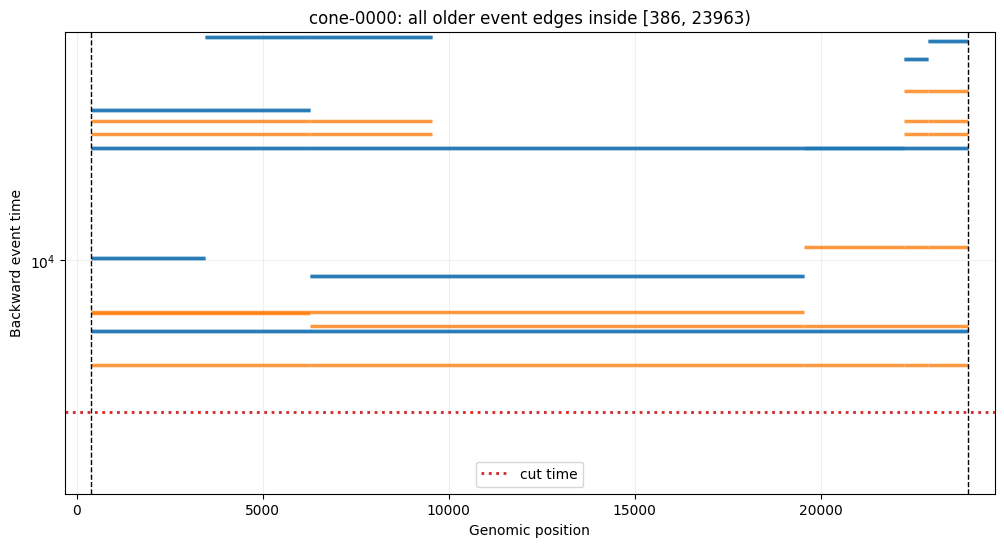

In [8]:
def resolve_closed_cone(cone_or_id):
    if isinstance(cone_or_id, dict):
        return cone_or_id
    if isinstance(cone_or_id, (int, np.integer)):
        return exact_closed_cones[int(cone_or_id)]
    for cone in exact_closed_cones:
        if cone["cone_id"] == cone_or_id:
            return cone
    raise KeyError(cone_or_id)


def inspect_closed_cone(cone_or_id):
    cone = resolve_closed_cone(cone_or_id)
    event_rows = []
    edge_rows = []
    for event_index in cone["suffix_event_indices"]:
        event = trace.event_at_index(event_index)
        event_rows.append(
            {
                "event_index": event_index,
                "kind": event.kind,
                "time": event.time,
                "node_ids": event.node_ids,
                "edge_count": len(event.edge_ids),
            }
        )
        for edge_id in event.edge_ids:
            edge_rows.append(
                {
                    "edge_id": edge_id,
                    "event_index": event_index,
                    "event_kind": event.kind,
                    "event_time": event.time,
                    "left": float(trace.edge_left[edge_id]),
                    "right": float(trace.edge_right[edge_id]),
                    "parent": int(trace.edge_parent[edge_id]),
                    "child": int(trace.edge_child[edge_id]),
                }
            )
    node_rows = [
        {
            "node_id": node_id,
            "time": float(trace.node_time[node_id]),
            "flags": int(trace.node_flags[node_id]),
            "is_recombination": bool(
                int(trace.node_flags[node_id]) & int(NODE_IS_RE_EVENT)
            ),
        }
        for node_id in cone["node_ids"]
    ]
    frontier_rows = [
        {"node_id": node_id, "left": left, "right": right}
        for node_id, left, right in cone["frontier_segments"]
    ]
    summary = {
        key: cone[key]
        for key in (
            "cone_id",
            "left",
            "right",
            "span",
            "first_closed_step",
            "first_closed_time",
            "separation_event_index",
            "separation_event_kind",
            "event_count",
            "node_count",
            "edge_count",
            "valid_cut_count",
        )
    }
    return {
        "summary": summary,
        "frontier_segments": pd.DataFrame(frontier_rows),
        "events": pd.DataFrame(event_rows),
        "nodes": pd.DataFrame(node_rows),
        "edges": pd.DataFrame(edge_rows),
    }


def plot_closed_cone(cone_or_id, ax=None):
    cone = resolve_closed_cone(cone_or_id)
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))
    colors = {"coalescence": "tab:blue", "recombination": "tab:orange"}
    for event_index in cone["suffix_event_indices"]:
        event = trace.event_at_index(event_index)
        for edge_id in event.edge_ids:
            ax.hlines(
                event.time,
                float(trace.edge_left[edge_id]),
                float(trace.edge_right[edge_id]),
                color=colors.get(event.kind, "0.4"),
                linewidth=2.5,
                alpha=0.8,
            )
    ax.axvline(cone["left"], color="black", linestyle="--", linewidth=1)
    ax.axvline(cone["right"], color="black", linestyle="--", linewidth=1)
    ax.axhline(
        cone["first_closed_time"],
        color="tab:red",
        linestyle=":",
        linewidth=2,
        label="cut time",
    )
    ax.set_xlim(cone["left"] - 0.03 * cone["span"], cone["right"] + 0.03 * cone["span"])
    ax.set_yscale("symlog", linthresh=1.0)
    ax.set_xlabel("Genomic position")
    ax.set_ylabel("Backward event time")
    ax.set_title(
        f"{cone['cone_id']}: all older event edges inside "
        f"[{cone['left']:.0f}, {cone['right']:.0f})"
    )
    ax.grid(alpha=0.2)
    ax.legend()
    return ax


selected_cone = max(exact_closed_cones, key=lambda cone: cone["event_count"])
selected_cone_details = inspect_closed_cone(selected_cone)
display(selected_cone_details["summary"])
display(selected_cone_details["frontier_segments"])
display(selected_cone_details["events"])
display(selected_cone_details["edges"])
plot_closed_cone(selected_cone)
plt.show()


## Live objects

- `synthetic_arg` is the certified 25 kb synthetic/full ARG.
- `trace` is its strictly time-ordered `FastARGTrace`.
- `per_cut_component_catalog` contains every raw component at every cut, including zero-event, noncontiguous, and whole-sequence diagnostics.
- `exact_closed_cones` contains every minimal nonempty exact cone, deduplicated to its earliest cut.
- `exact_closed_cones_df` and `per_cut_summary_df` provide compact tabular summaries.
- `inspect_closed_cone(...)` and `plot_closed_cone(...)` provide detailed inspection.